In [25]:
!pip install matplotx
!pip install seaborn
!pip install statsmodels

In [26]:
import matplotx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use(matplotx.styles.github['dark'])

In [27]:
df = pd.read_csv("./fm_data.csv")
df.head()

,Unnamed: 0,Username,Artist,Track,Album,Date,Time
0,0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


# Feature Engineering:
- **Time periods:** Using the given timestamps, convert it to distinct time periods such as “Morning”, “Noon”, “Afternoon”, etc.
- **Days of the week:** Convert the day column to find out whether a song is heavily played on weekends vs weekdays. This can suggest party / relaxed vibes or work / focus vibes. Different days of the week can be analysed.

In [28]:
# Combine and parse
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.sort_values('datetime').reset_index(drop=True)

# Derived time features
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['date_only']   = df['datetime'].dt.date

def time_period(hour):
    if 5 <= hour < 12:  return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:               return 'Night'

df['period'] = df['hour'].apply(time_period)

In [29]:
df

,Unnamed: 0,Username,Artist,Track,Album,Date,Time,datetime,hour,day_of_week,date_only,period
0,85995,eartle,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,0,Friday,2021-01-01,Night
1,256448,Orlenay,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,0,Friday,2021-01-01,Night
2,208790,jonocole,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,0,Friday,2021-01-01,Night
3,16217,Babs_05,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,0,Friday,2021-01-01,Night
4,46106,franhale,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,0,Friday,2021-01-01,Night
...,...,...,...,...,...,...,...,...,...,...,...,...
166148,260408,Orlenay,Al Bowlly,Experiment,1930s Classics,31 Jan 2021,23:59,2021-01-31 23:59:00,23,Sunday,2021-01-31,Night
166149,256751,Orlenay,Alex Turner,Glass in the Park,Submarine,31 Jan 2021,23:59,2021-01-31 23:59:00,23,Sunday,2021-01-31,Night
166150,64682,franhale,Perfume Genius,Jason,Set My Heart on Fire Immediately,31 Jan 2021,23:59,2021-01-31 23:59:00,23,Sunday,2021-01-31,Night
166151,90875,eartle,Eddie Chacon,Above Below - Nick Hakim Remix,Above Below (Nick Hakim Remix),31 Jan 2021,23:59,2021-01-31 23:59:00,23,Sunday,2021-01-31,Night


# Co-occurrence (Collaborative Vibes):
- Use dimensionality reduction techniques like **PCA (Principal Component Analysis)** or **SVD** to compress this massive table into smaller numerical vectors (embeddings) for each track.
- Build a **user-track matrix** (a table where rows are tracks, columns are users, and values are play counts).


In [30]:
# Create a unique song ID (artist + track avoids collisions)
df['song_id'] = df['Artist'] + ' — ' + df['Track']

# Play count matrix
play_counts = df.groupby(['Username', 'song_id']).size().reset_index(name='plays')

# Encode rows/cols as integers
user_enc = LabelEncoder()
song_enc = LabelEncoder()
play_counts['user_idx'] = user_enc.fit_transform(play_counts['Username'])
play_counts['song_idx'] = song_enc.fit_transform(play_counts['song_id'])

n_users = play_counts['user_idx'].nunique()
n_songs = play_counts['song_idx'].nunique()

# Sparse matrix: rows=users, cols=songs, values=play counts
R = csr_matrix(
    (play_counts['plays'], (play_counts['user_idx'], play_counts['song_idx'])),
    shape=(n_users, n_songs)
)

# SVD: decompose into latent factors
# n_components controls embedding dimensionality — tune this (32–128 is typical)
svd = TruncatedSVD(n_components=50, random_state=42)
svd.fit(R)

# Song embeddings: V^T matrix, shape (n_songs, 50)
song_embeddings = svd.components_.T  # shape: (n_songs, 50)

# Map song names back to their embedding index
song_to_idx = {song: idx for idx, song in enumerate(song_enc.classes_)}

# K - Means

In [31]:

# L2-normalize embeddings before clustering (important for cosine-like behavior)
embeddings_norm = normalize(song_embeddings)

# Choose k — you can use elbow/silhouette to tune, start with ~8–15
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(embeddings_norm)

# Build lookup: song_id → cluster label
song_cluster_map = {
    song: kmeans.labels_[song_to_idx[song]]
    for song in song_to_idx
}

# Attach cluster label to each listening event
df['cluster'] = df['song_id'].map(song_cluster_map)

# Time - Series

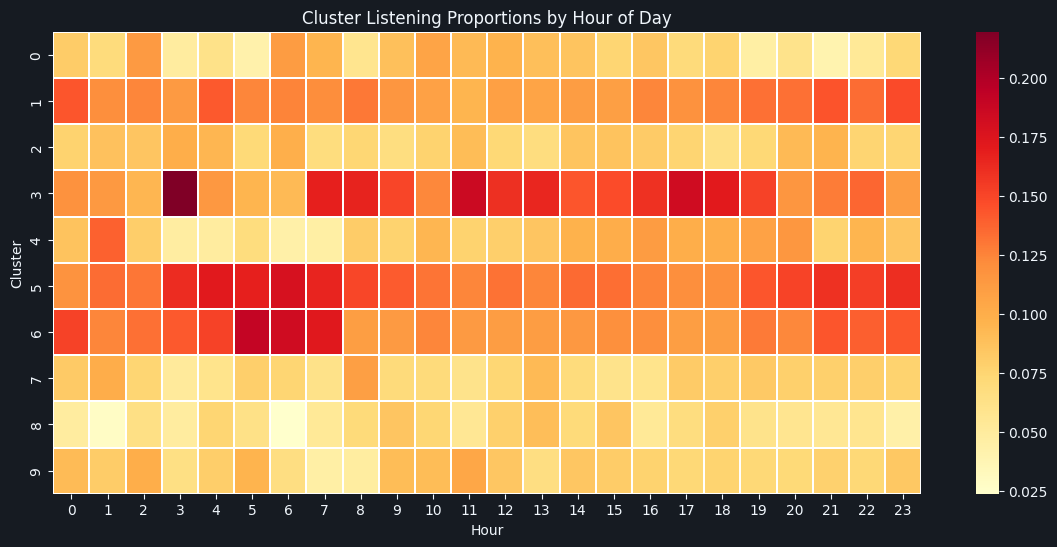

In [32]:
pivot = df.groupby(['hour', 'cluster']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)  # normalize to proportions

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_pct.T, cmap='YlOrRd', linewidths=0.3)
plt.title('Cluster Listening Proportions by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Cluster')
plt.show()

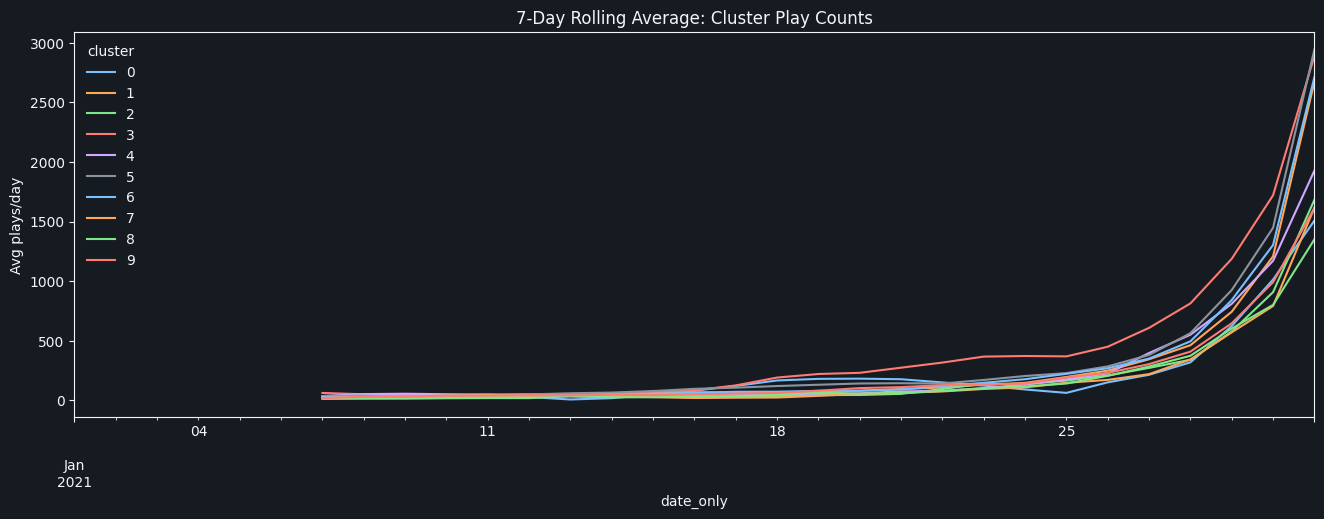

In [33]:
# Daily cluster counts
daily = df.groupby(['date_only', 'cluster']).size().unstack(fill_value=0)
daily.index = pd.to_datetime(daily.index)

# 7-day rolling mean
rolling = daily.rolling(7).mean()

rolling.plot(figsize=(16, 5), title='7-Day Rolling Average: Cluster Play Counts')
plt.ylabel('Avg plays/day'); plt.show()

<Axes: title={'center': 'Listening Diversity Over Time'}, xlabel='date_only'>

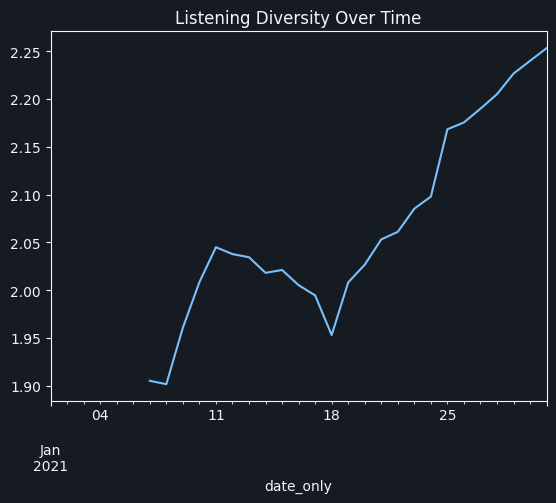

In [34]:
from scipy.stats import entropy

def row_entropy(row):
    p = row / row.sum()
    return entropy(p + 1e-9)

daily['entropy'] = daily.apply(row_entropy, axis=1)
daily['entropy'].rolling(7).mean().plot(title='Listening Diversity Over Time')

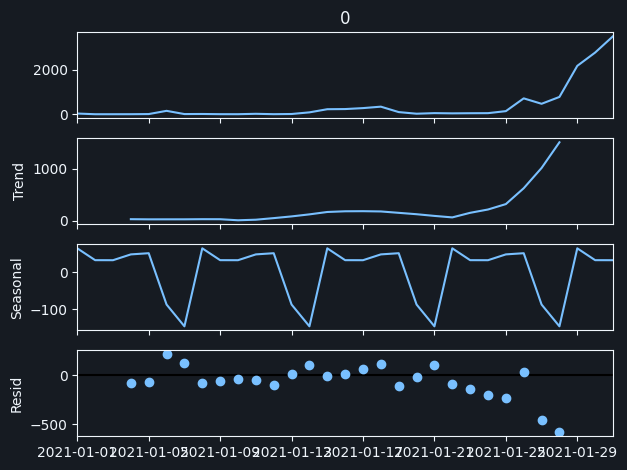

In [35]:
cluster_ts = daily[0].asfreq('D').fillna(0)  # pick a cluster
result = seasonal_decompose(cluster_ts, model='additive', period=7)
result.plot()
plt.show()